In [1]:
from langchain_community.document_loaders import PyPDFLoader

from pdf2image import convert_from_path
import pytesseract

from PIL import Image
import matplotlib.pyplot as plt

import os, time, io

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

from dotenv import load_dotenv
load_dotenv()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15104\1223279294.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [2]:
pdf1 = r"D:\prac_r\DummyJD.pdf"
pdf2 = r"D:\prac_r\Accenture_AI_ML_Engineer_JD.pdf"
poppler_path = r'C:\Program Files\poppler-26.02.0\Library\bin'

In [3]:
start = time.time()

loader1 = PyPDFLoader(pdf1)
docs = loader1.load()

pdf1_text = "\n".join(doc.page_content for doc in docs)

end = time.time()

print("=" * 10)
print("PyPDFLoader Results")
print("=" * 10)

print(f"Characters Extracted : {len(pdf1_text.strip())}")
print(f"Execution Time       : {end-start:.2f} seconds")

print("\nPreview:\n")
print(pdf1_text[:1000])

PyPDFLoader Results
Characters Extracted : 0
Execution Time       : 0.12 seconds

Preview:





In [4]:
start = time.time()
images1 = convert_from_path(pdf1, poppler_path=poppler_path)
end = time.time()

print(f"Pages: {len(images1)}")
print(f"Conversion Time: {end-start:.2f} seconds")


Pages: 2
Conversion Time: 0.24 seconds


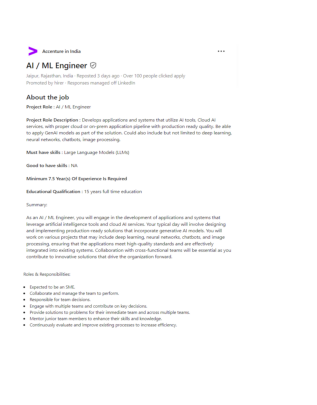

In [5]:
plt.figure(figsize=(8,5))
plt.imshow(images1[0])
plt.axis("off")
plt.show()

In [6]:
vision_llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    api_key= os.getenv("GROQ_API_KEY"),
    temperature=0
)

In [7]:
prompt = """
You are an OCR assistant.

Extract ALL text exactly as it appears in the document.

Rules:

- Preserve headings.
- Preserve bullet points.
- Preserve formatting whenever possible.
- Do NOT summarize.
- Do NOT explain.
- Return only the extracted text.
"""

In [8]:
import base64
import io
import time

full_text = ""

for page_no, image in enumerate(images1):

    buffer = io.BytesIO()

    image.save(
        buffer,
        format="PNG"
    )

    image_b64 = base64.b64encode(
        buffer.getvalue()
    ).decode("utf-8")

    message = HumanMessage(
        content=[
            {
                "type": "text",
                "text": prompt
            },
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{image_b64}"
                }
            }
        ]
    )

    response = vision_llm.invoke([message])

    full_text += (
        f"\n\n========== PAGE {page_no+1} ==========\n\n"
    )

    full_text += response.content

    print(
        f"Page {page_no+1} processed."
    )

    time.sleep(5)

print(full_text)

Page 1 processed.
Page 2 processed.


========== PAGE 1 ==========

> Accenture in India

AI / ML Engineer 
Jaipur, Rajasthan, India · Reposted 3 days ago · Over 100 people clicked apply
Promoted by hirer · Responses managed off LinkedIn

## About the job

Project Role : AI / ML Engineer

Project Role Description : Develops applications and systems that utilize AI tools, Cloud AI services, with proper cloud or on-prem application pipeline with production ready quality. Be able to apply GenAI models as part of the solution. Could also include but not limited to deep learning, neural networks, chatbots, image processing.

Must have skills : Large Language Models (LLMs)

Good to have skills : NA

Minimum 7.5 Year(s) Of Experience Is Required

Educational Qualification : 15 years full time education

## Summary:

As an AI / ML Engineer, you will engage in the development of applications and systems that leverage artificial intelligence tools and cloud AI services. Your typical day will inv